In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 1: Exploratory Data Analysis

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DataSet/Crop_recommendation.csv')

In [ ]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [ ]:
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [ ]:
df.shape


(2200, 8)

In [ ]:
df.isna()

,N,P,K,temperature,humidity,ph,rainfall,label
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2195,False
2196,False
2197,False
2198,False


In [ ]:
duplicated_count = df.duplicated().sum()
duplicated_count

np.int64(0)

In [ ]:
df.nunique()

,0
N,137
P,117
K,73
temperature,2200
humidity,2200
ph,2200
rainfall,2200
label,22


In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
label_counts = df['label'].value_counts()
label_counts

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


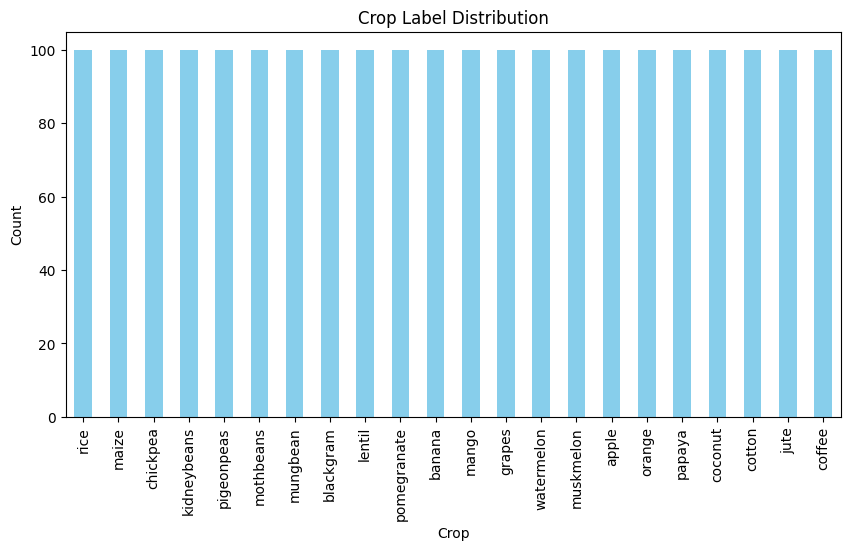

In [ ]:
plt.figure(figsize=(10,5))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Crop Label Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
df.head(3)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice


In [ ]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [ ]:
X = df[['N' ,'P' ,'K' ,'temperature' ,'humidity' ,'ph' ,'rainfall']]

In [ ]:
y = df['label']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1607,0,18,14,29.771494,92.007200,7.207991,114.416179
1212,9,122,201,29.587484,80.919344,5.570291,68.064173
362,11,71,24,21.140114,22.718235,5.606620,141.605672
566,38,38,18,26.310518,61.187491,6.294130,35.734038
1671,18,12,8,12.590940,91.816688,6.206053,119.391672
...,...,...,...,...,...,...,...
808,13,64,20,19.134577,62.575269,6.590571,36.469470
422,16,55,19,19.543141,47.191883,6.413544,192.437219
2052,82,48,36,25.793520,81.769040,6.352077,193.241838
2083,90,50,44,26.916437,73.486560,6.253409,171.471638


In [ ]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
1609,13,23,6,23.961476,90.264080,7.365338,102.695870
1072,98,79,50,25.341198,84.473213,6.435917,91.064934
1912,140,38,15,24.147295,75.882986,6.021440,69.915635
100,71,54,16,22.613600,63.690706,5.749914,87.759539
1645,40,22,6,24.536101,91.909972,6.488221,115.978799
...,...,...,...,...,...,...,...
140,99,56,17,24.108592,73.131123,6.234330,71.075622
1587,1,135,203,22.778565,92.701240,5.624203,113.775922
2015,70,38,35,24.397362,79.268617,7.014064,164.269701
1254,21,134,202,10.723025,80.021306,6.425420,65.298211


In [ ]:
y_train

,label
1607,orange
1212,grapes
362,kidneybeans
566,mothbeans
1671,orange
...,...
808,lentil
422,pigeonpeas
2052,jute
2083,jute


In [ ]:
y_test

,label
1609,orange
1072,banana
1912,cotton
100,maize
1645,orange
...,...
140,maize
1587,apple
2015,jute
1254,grapes


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_trained_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [ ]:
X_trained_scaled_df

,N,P,K,temperature,humidity,ph,rainfall
0,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440
1,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677
2,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001
3,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744
4,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941
...,...,...,...,...,...,...,...
1755,-1.018869,0.323643,-0.555154,-1.274842,-0.396933,0.149081,-1.218366
1756,-0.937463,0.050404,-0.574880,-1.194399,-1.087561,-0.076988,1.618598
1757,0.853467,-0.162115,-0.239537,0.036250,0.464759,-0.155483,1.633233
1758,1.070550,-0.101395,-0.081729,0.257343,0.092922,-0.281484,1.237246


In [ ]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
X_test_scaled_df

,N,P,K,temperature,humidity,ph,rainfall
0,-1.018869,-0.921110,-0.831318,-0.324465,0.846139,1.138481,-0.013746
1,1.287632,0.779040,0.036628,-0.052809,0.586161,-0.048416,-0.225306
2,2.427316,-0.465713,-0.653784,-0.287878,0.200508,-0.577716,-0.610000
3,0.554979,0.020044,-0.634058,-0.589851,-0.346857,-0.924461,-0.285429
4,-0.286216,-0.951470,-0.831318,-0.211326,0.920030,0.018378,0.227863
...,...,...,...,...,...,...,...
435,1.314768,0.080764,-0.614332,-0.295499,0.076965,-0.305848,-0.588900
436,-1.344493,2.479191,3.054713,-0.557370,0.955554,-1.084998,0.187794
437,0.527844,-0.465713,-0.259263,-0.238642,0.352504,0.689894,1.106247
438,-0.801787,2.448831,3.034987,-2.931009,0.386296,-0.061821,-0.693988


In [ ]:
models = {
    "Random Forest" : RandomForestClassifier(n_estimators=200,random_state=42),
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "KNN" : KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression" : LogisticRegression(max_iter=200,random_state=42),
    "SVM(RBF Kernel)" : SVC(kernel='rbf', random_state=42),
}

In [ ]:
results = []
for name,model in models.items():
  if name in ["KNN","Logistic Regression","SVM(RBF Kernel)"]:
    model.fit(X_train_scaled,y_train)
    preds = model.predict(X_test_scaled)
  else:
    model.fit(X_train,y_train)
    preds = model.predict(X_test)


  acc = accuracy_score(y_test,preds)
  results.append((name,acc))

In [ ]:
results

[('Random Forest', 0.9954545454545455),
 ('Decision Tree', 0.9795454545454545),
 ('KNN', 0.9795454545454545),
 ('Logistic Regression', 0.9727272727272728),
 ('SVM(RBF Kernel)', 0.9840909090909091)]

In [ ]:
results_df = pd.DataFrame(results,columns=["Model","Accuracy"])
results_df

,Model,Accuracy
0,Random Forest,0.995455
1,Decision Tree,0.979545
2,KNN,0.979545
3,Logistic Regression,0.972727
4,SVM(RBF Kernel),0.984091


In [ ]:
results_df = results_df.sort_values(by="Accuracy",ascending=False)
results_df

,Model,Accuracy
0,Random Forest,0.995455
4,SVM(RBF Kernel),0.984091
1,Decision Tree,0.979545
2,KNN,0.979545
3,Logistic Regression,0.972727


In [ ]:
import pickle as pkl

In [ ]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train,y_train)
preds = best_model.predict(X_test)
acc = accuracy_score(y_test,preds)
print(f"Best Model Accuracy: {acc}")

Best Model Accuracy: 0.9954545454545455


In [ ]:
best_model.classes_

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

In [ ]:
bundle = {
    "model" : best_model,
    "feature_cols" : ['N','P','K','temperature','humidity','ph','rainfall'],
    "classes" : best_model.classes_
}

In [ ]:
with open('Crop_recommendation_RF.pkl','wb') as f:
  pkl.dump(bundle,f)
  print("Model saved as Crop_recommendation_RF.pkl")

Model saved as Crop_recommendation_RF.pkl


In [ ]:
with open('Crop_recommendation_RF.pkl','rb') as f:
  b = pkl.load(f)

In [ ]:
print(type(b["model"]) , b["feature_cols"], b["classes"][:3] )

<class 'sklearn.ensemble._forest.RandomForestClassifier'> ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'] ['apple' 'banana' 'blackgram']


In [ ]:
sample ={
    'N':90, 'P':40, 'K':40, 'temperature':20, 'humidity':80, 'ph':7, 'rainfall':200
}
X = [[sample [c]for c in b["feature_cols"]]]
X

[[90, 40, 40, 20, 80, 7, 200]]

In [ ]:
print("Pred:" ,b["model"].predict(X)[0])

Pred: rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
